In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

plt.rcParams["figure.figsize"] = (10,6)
sns.set_style("whitegrid")


In [3]:
# Load dataset
df = pd.read_csv("combined_weather_v2.csv")

# Inspect
print(df.head())
print(df.info())


             Date Time  Wind dir (deg)  Solar rad (W/m²)  Wind speed (m/s)  \
0  01/03/2025 00:00:00             339                -1               0.0   
1  01/03/2025 00:05:00             335                -1               0.4   
2  01/03/2025 00:10:00             329                -1               0.9   
3  01/03/2025 00:15:00             326                -1               0.7   
4  01/03/2025 00:20:00             332                -1               0.8   

   Wind gust (m/s)  Temperature (°C)  Relative humidity (%)  Dew point (°C)  \
0              0.0              24.6                   84.8            22.0   
1              1.2              24.4                   86.1            22.0   
2              1.7              24.3                   86.5            22.0   
3              0.9              24.3                   86.4            22.0   
4              1.2              24.4                   86.2            22.0   

   Atm pressure. (hPa)  Max rain rate (mm/h)  Daily rain

In [4]:
# Parse Date Time
df["Date Time"] = pd.to_datetime(df["Date Time"], format='mixed', dayfirst=True, errors='coerce')

# Drop invalid dates if any
df = df.dropna(subset=["Date Time"])

# Sort
df = df.sort_values("Date Time").reset_index(drop=True)

# Create time features
df["Year"] = df["Date Time"].dt.year
df["Month"] = df["Date Time"].dt.month
df["Month Name"] = df["Date Time"].dt.month_name()
df["Day"] = df["Date Time"].dt.day
df["Hour"] = df["Date Time"].dt.hour
df["Weekday"] = df["Date Time"].dt.day_name()

df.head()


,Date Time,Wind dir (deg),Solar rad (W/m²),Wind speed (m/s),Wind gust (m/s),Temperature (°C),Relative humidity (%),Dew point (°C),Atm pressure. (hPa),Max rain rate (mm/h),...,Total Rainfall (mm),PM1.0 (µg/m³),PM2.5 (µg/m³),PM10 (µg/m³),Year,Month,Month Name,Day,Hour,Weekday
0,2025-03-01 00:00:00,339,-1,0.0,0.0,24.6,84.8,22.0,989.1,0,...,430.25,58.2,64.6,87.4,2025,3,March,1,0,Saturday
1,2025-03-01 00:05:00,335,-1,0.4,1.2,24.4,86.1,22.0,989.0,0,...,430.25,58.9,65.4,88.4,2025,3,March,1,0,Saturday
2,2025-03-01 00:10:00,329,-1,0.9,1.7,24.3,86.5,22.0,989.0,0,...,430.25,56.9,63.1,85.3,2025,3,March,1,0,Saturday
3,2025-03-01 00:15:00,326,-1,0.7,0.9,24.3,86.4,22.0,988.9,0,...,430.25,54.7,60.6,82.0,2025,3,March,1,0,Saturday
4,2025-03-01 00:20:00,332,-1,0.8,1.2,24.4,86.2,22.0,988.9,0,...,430.25,53.3,59.1,79.9,2025,3,March,1,0,Saturday


In [5]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
Date Time,95618,2025-08-15 00:33:06.658370,2025-03-01 00:00:00,2025-05-23 18:26:15,2025-08-14 18:27:30,2025-11-05 23:58:45,2026-02-05 05:00:00,NaN
Wind dir (deg),95618.0,161.138928,0.0,69.0,141.0,271.0,359.0,112.0401
Solar rad (W/m²),95618.0,182.545985,-1.0,-1.0,2.0,312.0,1116.0,274.0548
Wind speed (m/s),95618.0,0.800063,0.0,0.2,0.8,1.1,6.2,0.634512
Wind gust (m/s),95618.0,1.674382,0.0,0.7,1.6,2.5,11.6,1.345944
Temperature (°C),95618.0,27.959621,16.0,25.0,27.5,31.1,40.5,4.301341
Relative humidity (%),95618.0,67.660419,0.0,53.6,68.0,82.6,98.1,18.334885
Dew point (°C),95618.0,20.688116,-37.9,19.6,21.2,22.8,30.7,3.538061
Atm pressure. (hPa),95618.0,982.932551,972.4,980.0,982.5,985.9,993.6,3.924324
Max rain rate (mm/h),95618.0,0.264333,0.0,0.0,0.0,0.0,198.0,3.478626


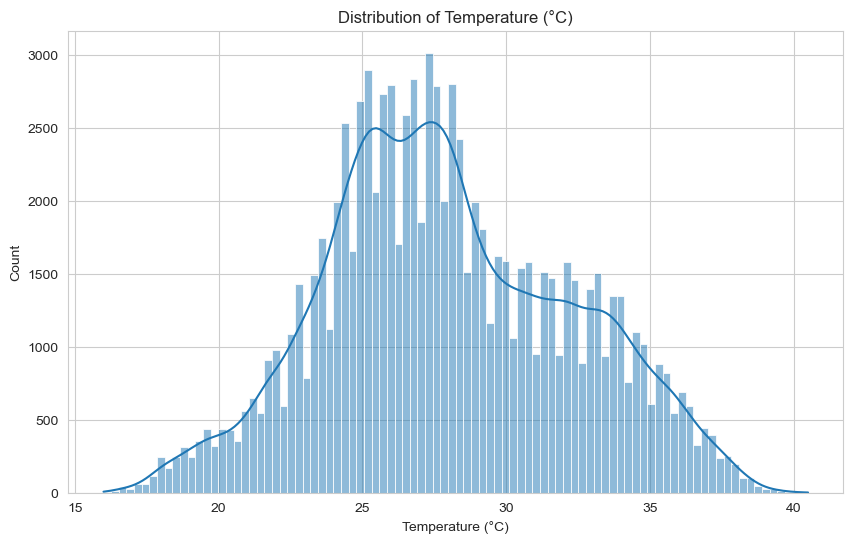

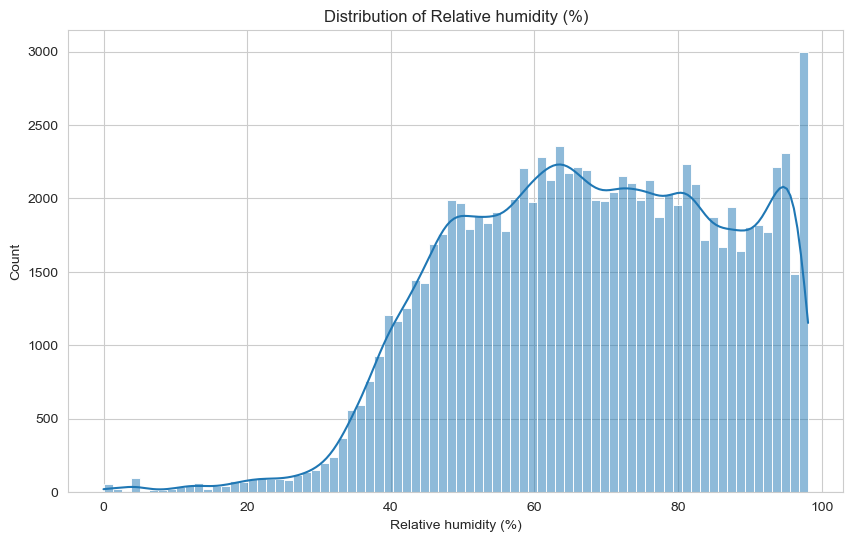

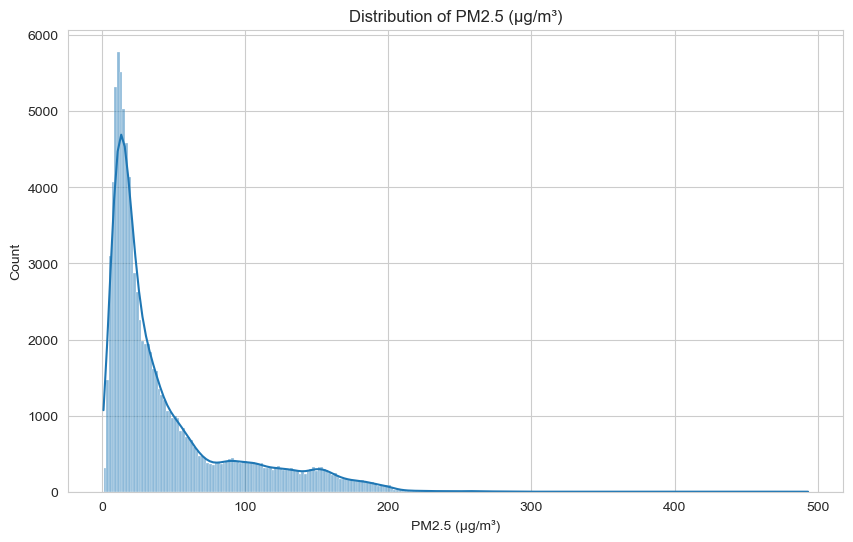

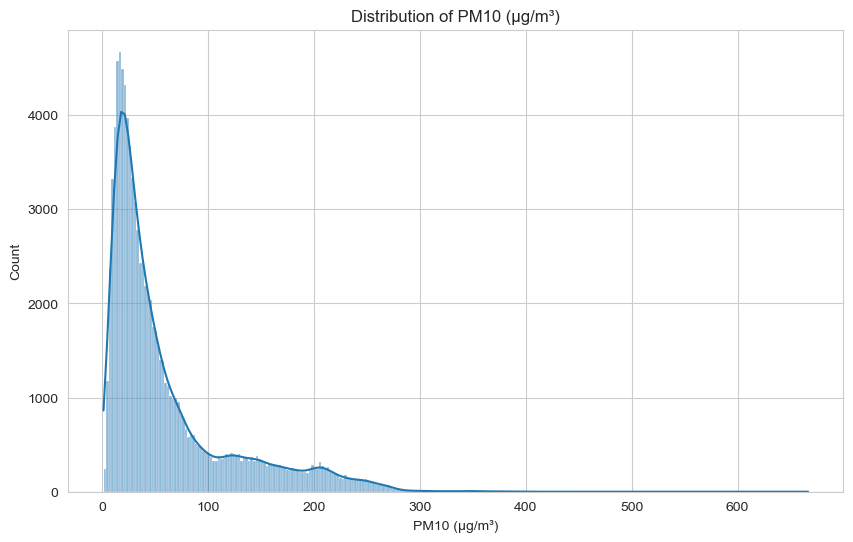

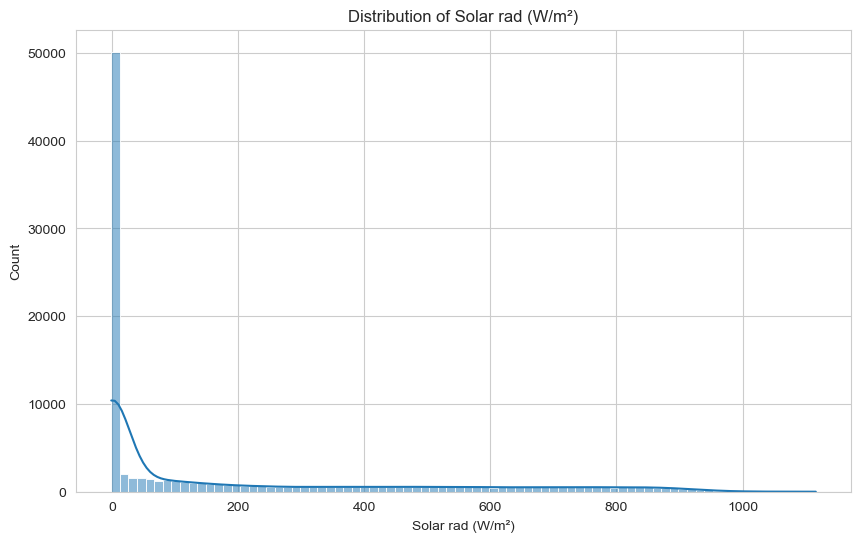

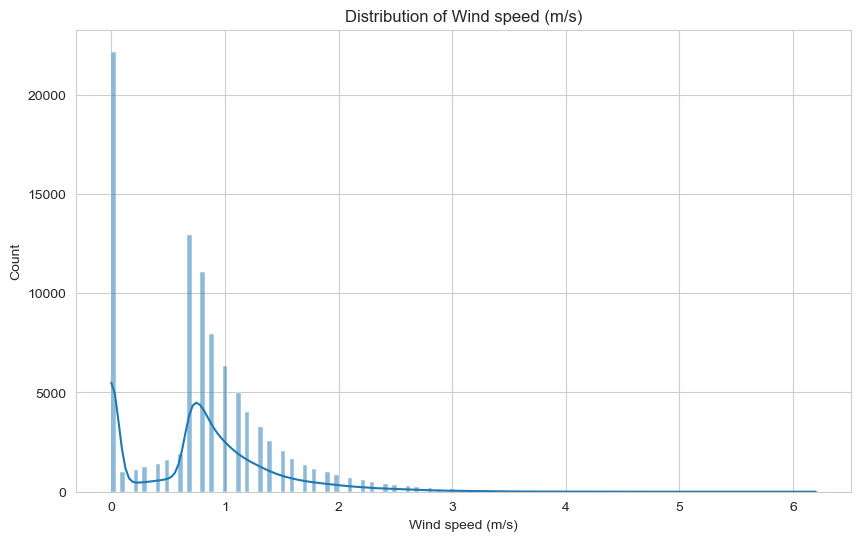

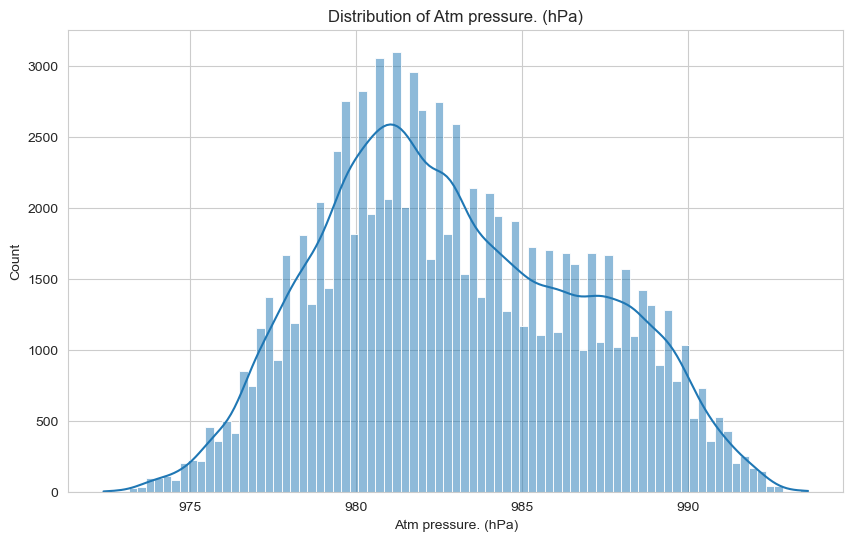

In [6]:
cols = ['Temperature (°C)', 'Relative humidity (%)',
        'PM2.5 (µg/m³)', 'PM10 (µg/m³)',
        'Solar rad (W/m²)', 'Wind speed (m/s)',
        'Atm pressure. (hPa)']

for col in cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


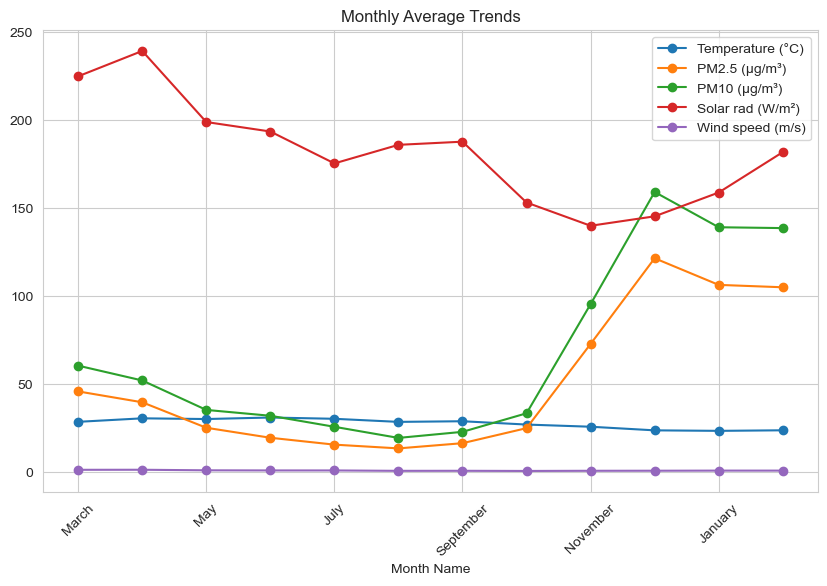

In [7]:
monthly_avg = df.groupby("Month Name").mean(numeric_only=True)

monthly_avg = monthly_avg.reindex([
    'March','April','May','June','July','August',
    'September','October','November','December','January','February'
])

monthly_avg[['Temperature (°C)', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)',
             'Solar rad (W/m²)', 'Wind speed (m/s)']].plot(marker='o')
plt.title("Monthly Average Trends")
plt.xticks(rotation=45)
plt.show()


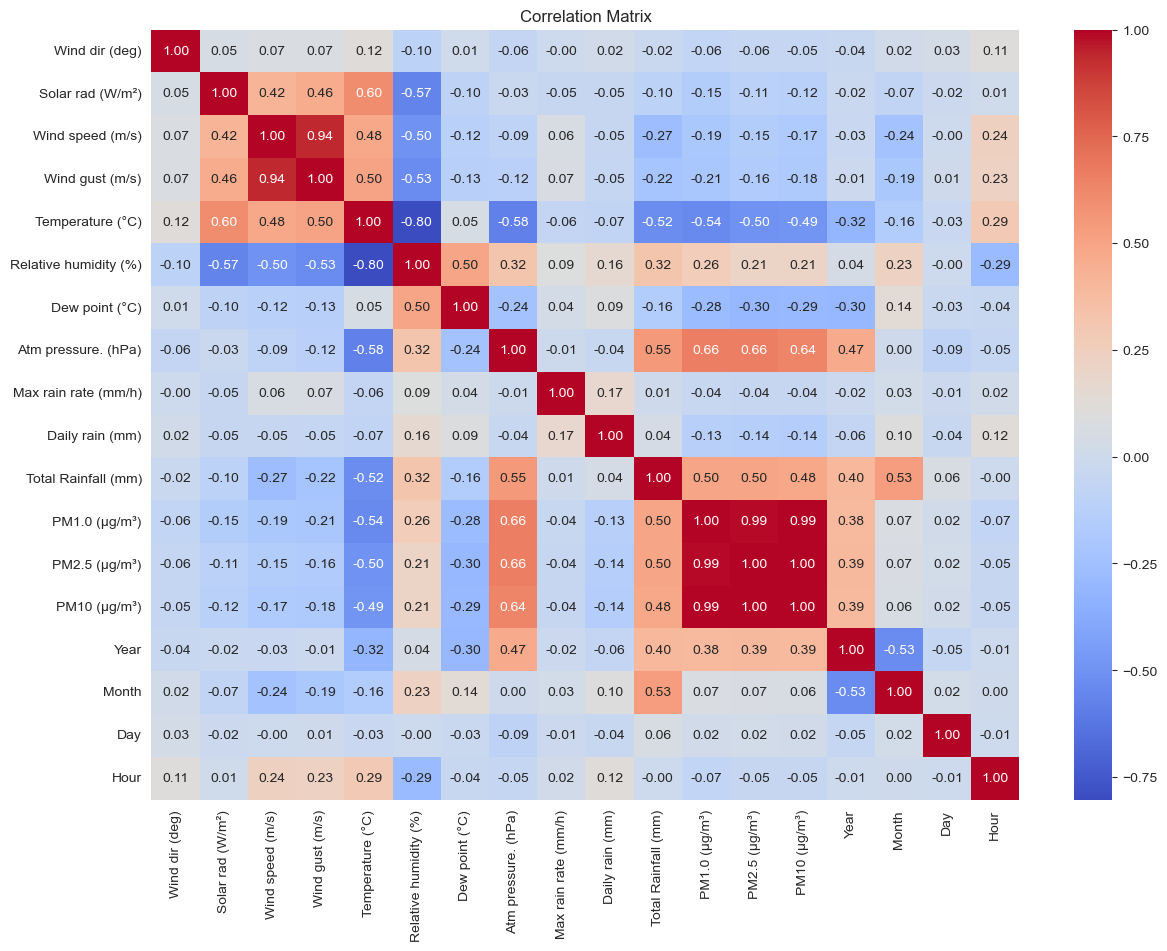

In [8]:
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()



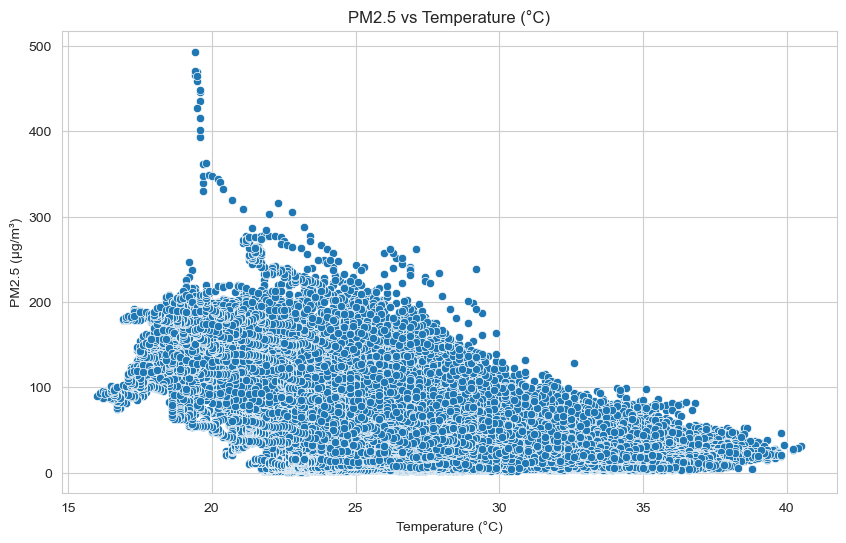

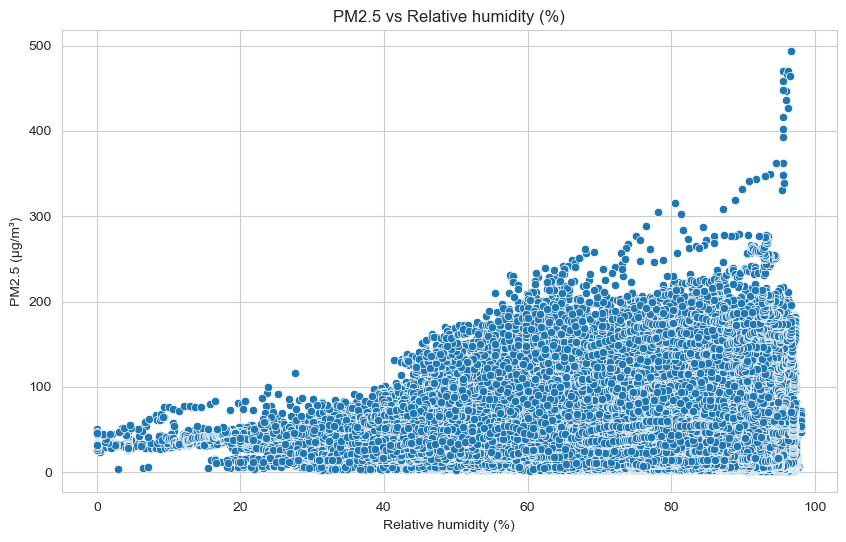

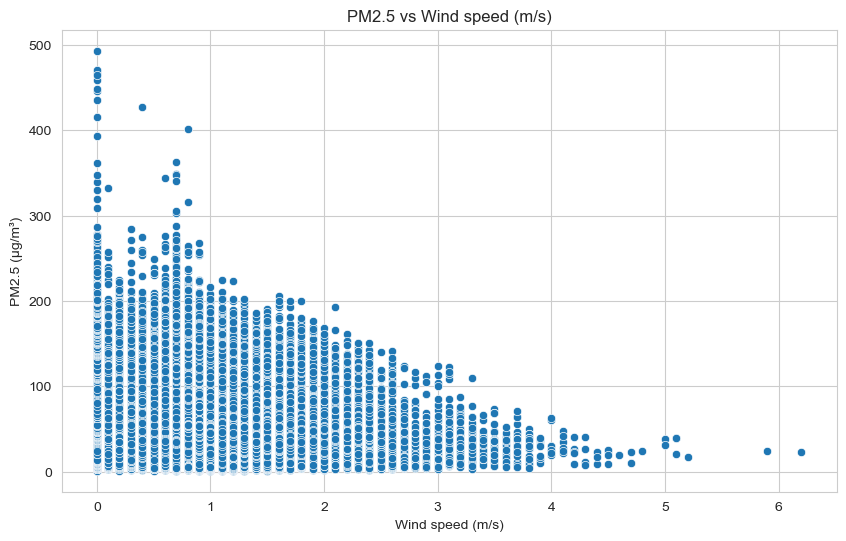

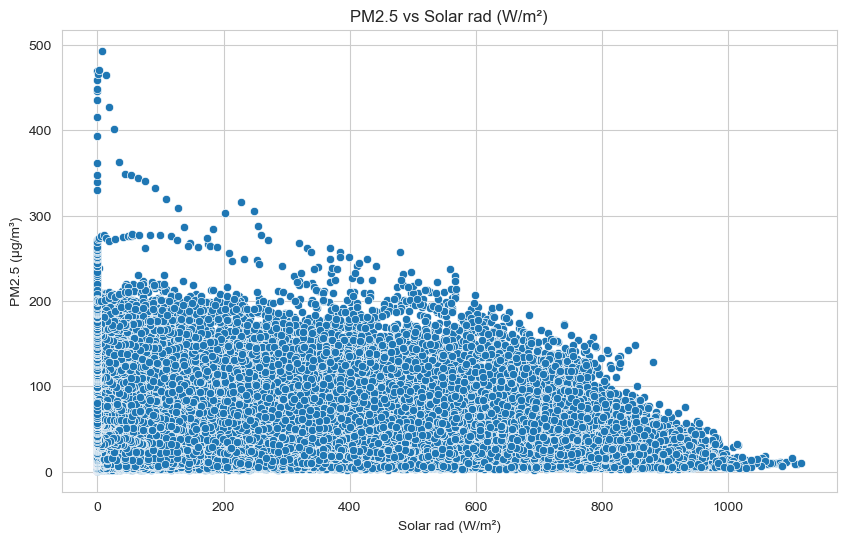

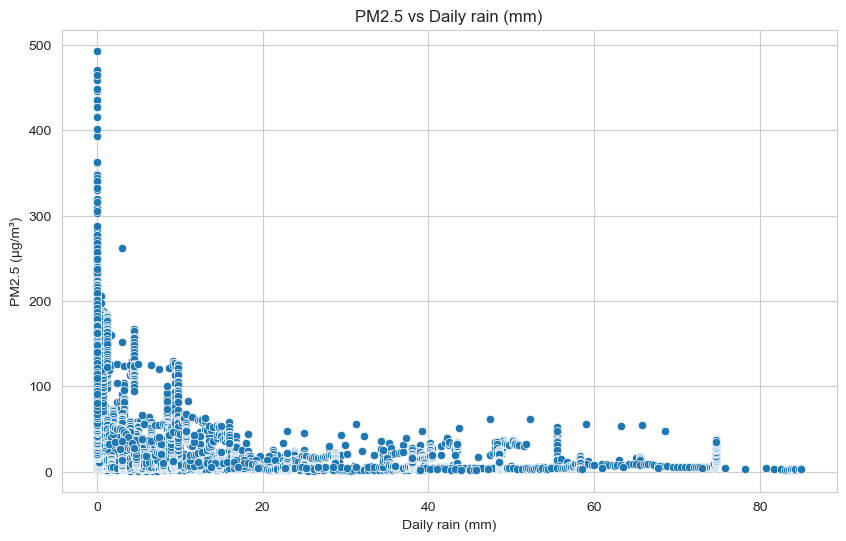

In [9]:
weather_cols = ['Temperature (°C)',
                'Relative humidity (%)',
                'Wind speed (m/s)',
                'Solar rad (W/m²)',
                'Daily rain (mm)']

for col in weather_cols:
    plt.figure()
    sns.scatterplot(x=df[col], y=df['PM2.5 (µg/m³)'])
    plt.title(f"PM2.5 vs {col}")
    plt.show()



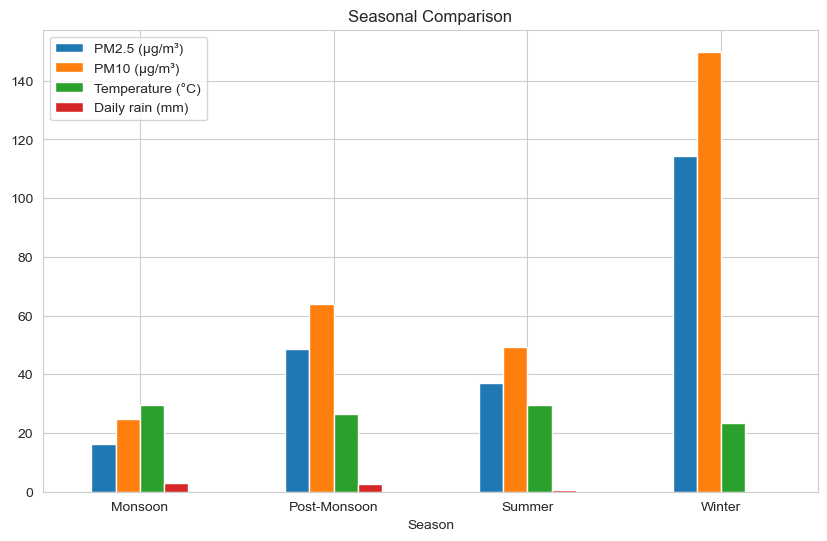

In [10]:
def get_season(month):
    if month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8,9]:
        return "Monsoon"
    elif month in [10,11]:
        return "Post-Monsoon"
    else:
        return "Winter"

df["Season"] = df["Month"].apply(get_season)

seasonal_avg = df.groupby("Season").mean(numeric_only=True)

seasonal_avg[['PM2.5 (µg/m³)', 'PM10 (µg/m³)',
              'Temperature (°C)', 'Daily rain (mm)']].plot(kind="bar")
plt.title("Seasonal Comparison")
plt.xticks(rotation=0)
plt.show()


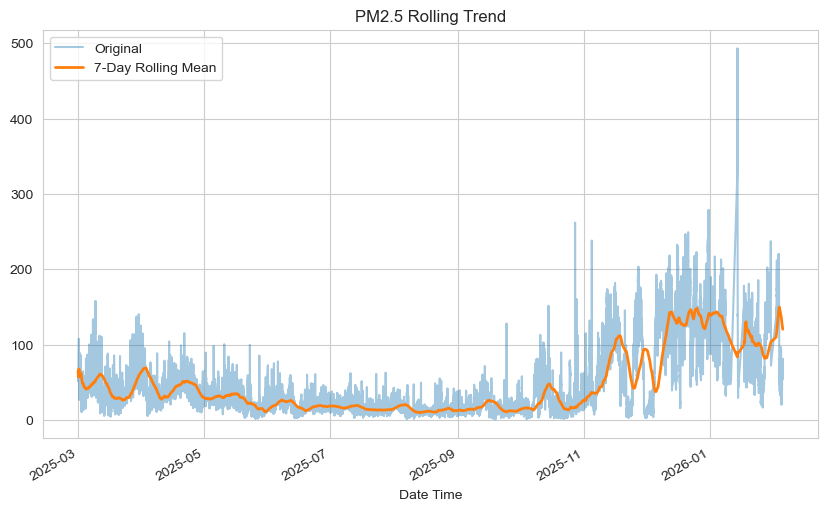

In [11]:
df.set_index("Date Time", inplace=True)

rolling_pm25 = df["PM2.5 (µg/m³)"].rolling("7D").mean()

plt.figure()
df["PM2.5 (µg/m³)"].plot(alpha=0.4, label="Original")
rolling_pm25.plot(label="7-Day Rolling Mean", linewidth=2)
plt.legend()
plt.title("PM2.5 Rolling Trend")
plt.show()


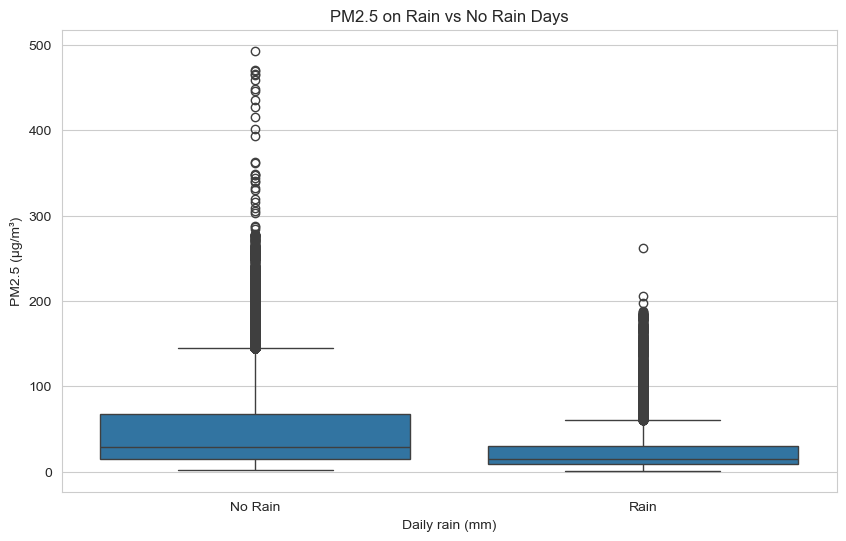

In [12]:
plt.figure()
sns.boxplot(x=df["Daily rain (mm)"] > 0, y=df["PM2.5 (µg/m³)"])
plt.xticks([0,1], ["No Rain", "Rain"])
plt.title("PM2.5 on Rain vs No Rain Days")
plt.show()


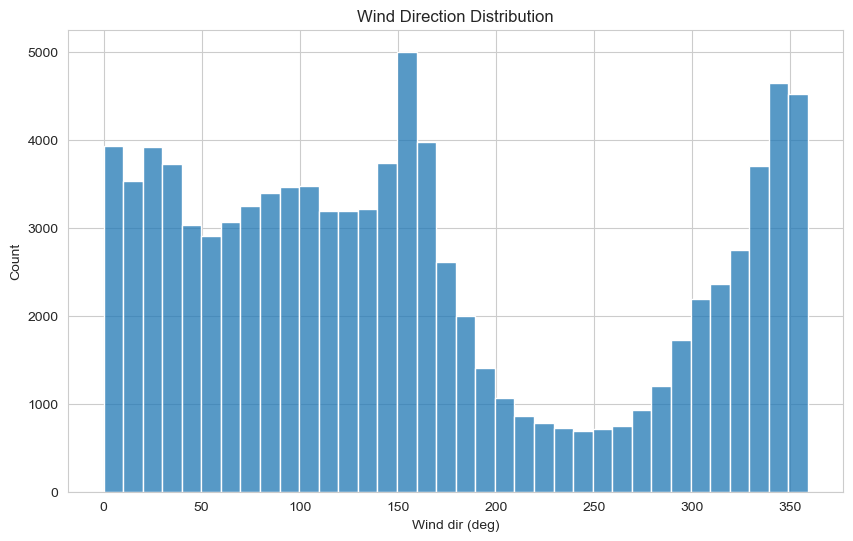

In [13]:
plt.figure()
sns.histplot(df["Wind dir (deg)"], bins=36)
plt.title("Wind Direction Distribution")
plt.show()


In [14]:
# High pollution days
high_pm = df[df["PM2.5 (µg/m³)"] > df["PM2.5 (µg/m³)"].quantile(0.95)]

print("Top 5% Pollution Days:")
print(high_pm[["PM2.5 (µg/m³)", "Temperature (°C)",
               "Wind speed (m/s)", "Relative humidity (%)"]].head())


Top 5% Pollution Days:
                     PM2.5 (µg/m³)  Temperature (°C)  Wind speed (m/s)  \
Date Time                                                                
2025-03-09 09:45:00          158.0              27.3               1.0   
2025-10-27 15:15:00          261.9              27.1               0.0   
2025-10-28 08:20:00          160.4              23.4               0.7   
2025-11-04 17:35:00          238.1              29.2               0.6   
2025-11-04 17:40:00          199.2              29.1               0.0   

                     Relative humidity (%)  
Date Time                                   
2025-03-09 09:45:00                   58.8  
2025-10-27 15:15:00                   77.1  
2025-10-28 08:20:00                   87.9  
2025-11-04 17:35:00                   70.5  
2025-11-04 17:40:00                   70.8  


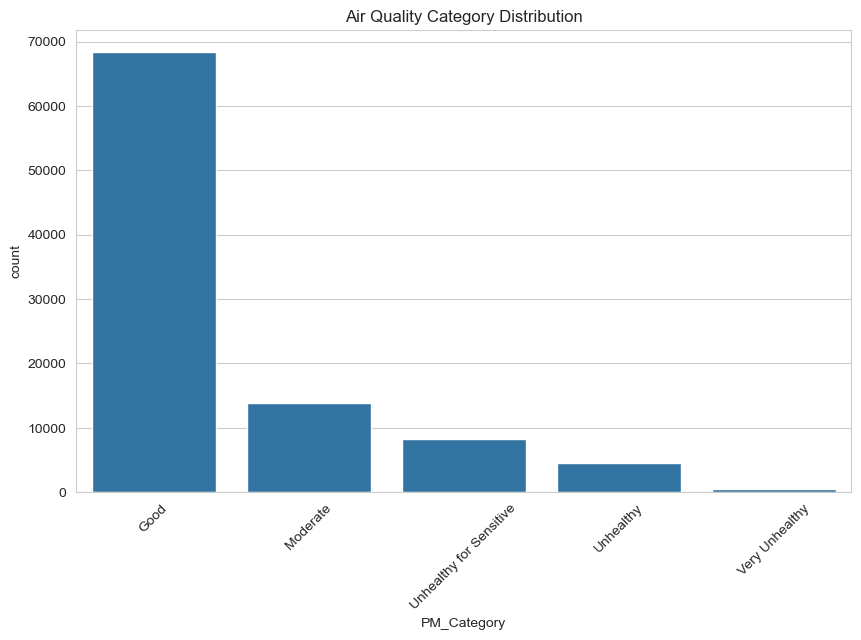

In [15]:
def pm25_category(val):
    if val <= 50:
        return "Good"
    elif val <= 100:
        return "Moderate"
    elif val <= 150:
        return "Unhealthy for Sensitive"
    elif val <= 200:
        return "Unhealthy"
    else:
        return "Very Unhealthy"

df["PM_Category"] = df["PM2.5 (µg/m³)"].apply(pm25_category)

sns.countplot(x=df["PM_Category"],
              order=df["PM_Category"].value_counts().index)
plt.title("Air Quality Category Distribution")
plt.xticks(rotation=45)
plt.show()


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)
sns.set_style("whitegrid")


In [17]:
df = pd.read_csv("PV_final_filtered.csv")

print(df.head())
print(df.info())


         Date  Month  Day      Time  Uncleaned_Voltage  Cleaned_Voltage  \
0  2025-03-03      3    3  12:55:00          38.112870        37.986869   
1  2025-03-03      3    3  13:00:00          37.707864        37.540750   
2  2025-03-03      3    3  13:05:00          37.691419        37.604307   
3  2025-03-03      3    3  13:10:00          37.781422        37.695308   
4  2025-03-03      3    3  13:15:00          37.551973        37.458638   

   Uncleaned_Current  Cleaned_Current       Full_Timestamp  \
0           1.669109         1.727692  2025-03-03 12:55:00   
1           1.652402         1.705385  2025-03-03 13:00:00   
2           1.653379         1.708030  2025-03-03 13:05:00   
3           1.656578         1.712615  2025-03-03 13:10:00   
4           1.646181         1.702564  2025-03-03 13:15:00   

   Power Curve_Uncleaned  Power Curve_Cleaned  Soiling loss  
0              63.614534            65.629606      3.070370  
1              62.308531            64.021439      2

In [18]:
df["Full_Timestamp"] = pd.to_datetime(df["Full_Timestamp"], errors="coerce")


In [19]:
df = df.sort_values("Full_Timestamp").reset_index(drop=True)

# Create time features
df["Year"] = df["Full_Timestamp"].dt.year
df["Month"] = df["Full_Timestamp"].dt.month
df["Hour"] = df["Full_Timestamp"].dt.hour
df["Day_of_Week"] = df["Full_Timestamp"].dt.day_name()


In [20]:
print("Missing Values:\n", df.isnull().sum())


Missing Values:
 Date                     0
Month                    0
Day                      0
Time                     0
Uncleaned_Voltage        0
Cleaned_Voltage          0
Uncleaned_Current        0
Cleaned_Current          0
Full_Timestamp           0
Power Curve_Uncleaned    0
Power Curve_Cleaned      0
Soiling loss             0
Year                     0
Hour                     0
Day_of_Week              0
dtype: int64


In [21]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Month,42883.0,7.283492,1.0,5.0,8.0,10.0,12.0,3.312328
Day,42883.0,15.749061,1.0,8.0,16.0,24.0,31.0,9.030617
Uncleaned_Voltage,42883.0,29.549589,0.000049,21.498516,37.227858,38.277206,41.742479,12.832961
Cleaned_Voltage,42883.0,29.402134,0.000052,21.931077,36.878298,37.947368,41.406142,12.646156
Uncleaned_Current,42883.0,1.637799,0.071681,1.214459,2.022273,2.096567,2.344865,0.676573
Cleaned_Current,42883.0,1.701139,0.084154,1.297036,2.080101,2.147109,2.790646,0.697224
Full_Timestamp,42883,2025-09-08 00:01:32.197374,2025-03-03 12:55:00,2025-06-24 11:57:30,2025-09-06 16:45:00,2025-11-24 06:42:30,2026-02-05 18:00:00,NaN
Power Curve_Uncleaned,42883.0,57.050701,0.000004,26.085545,75.352435,80.122635,97.798928,31.33046
Power Curve_Cleaned,42883.0,58.775108,0.000004,28.487259,76.707925,81.581179,111.293154,31.993923
Soiling loss,42883.0,3.627018,-1496.640353,1.209942,2.054141,4.247907,85.511376,10.742322


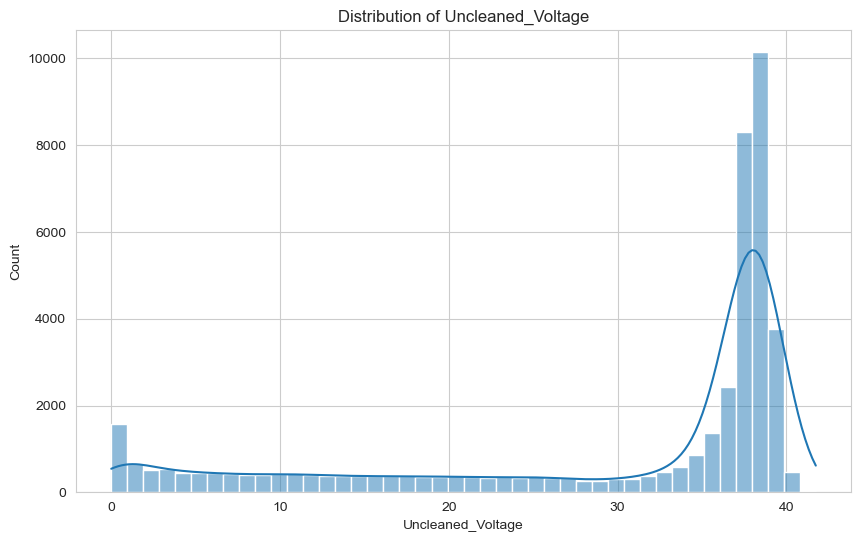

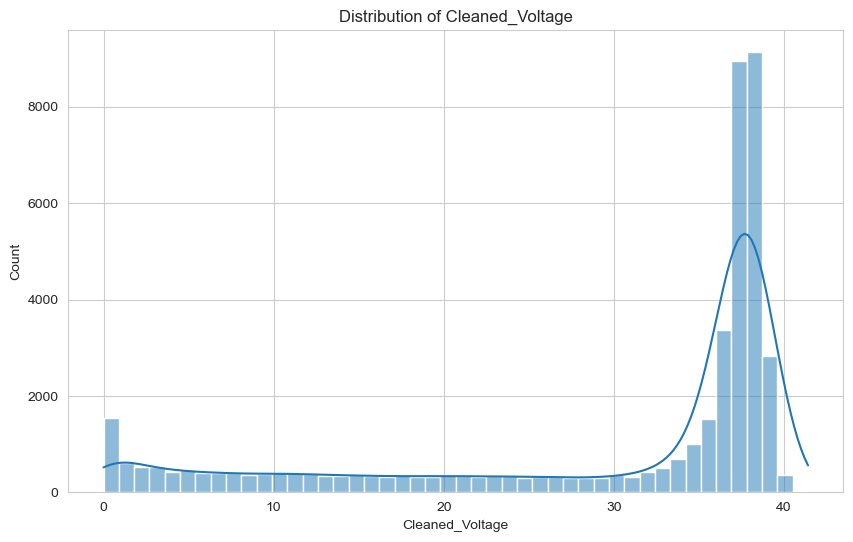

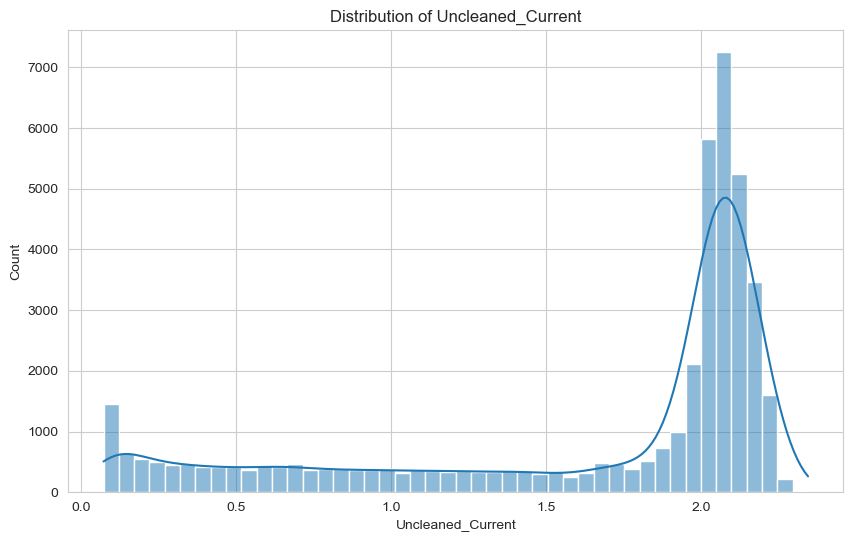

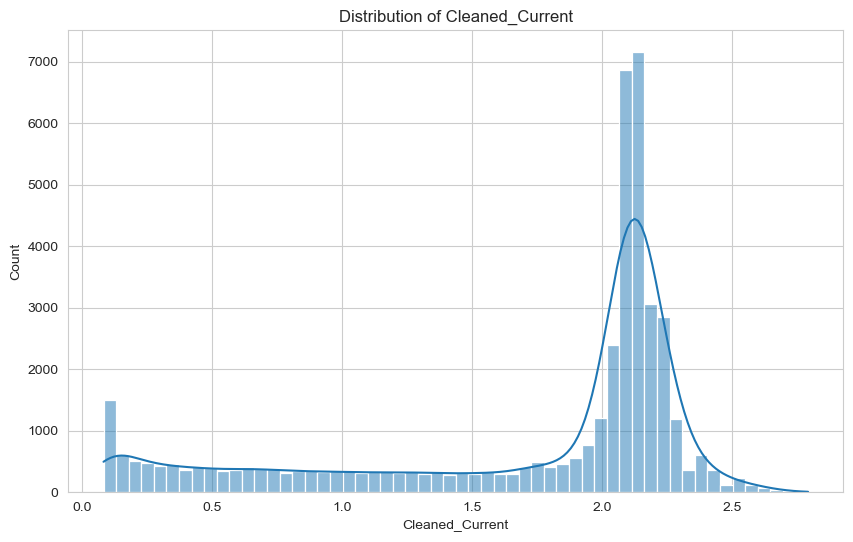

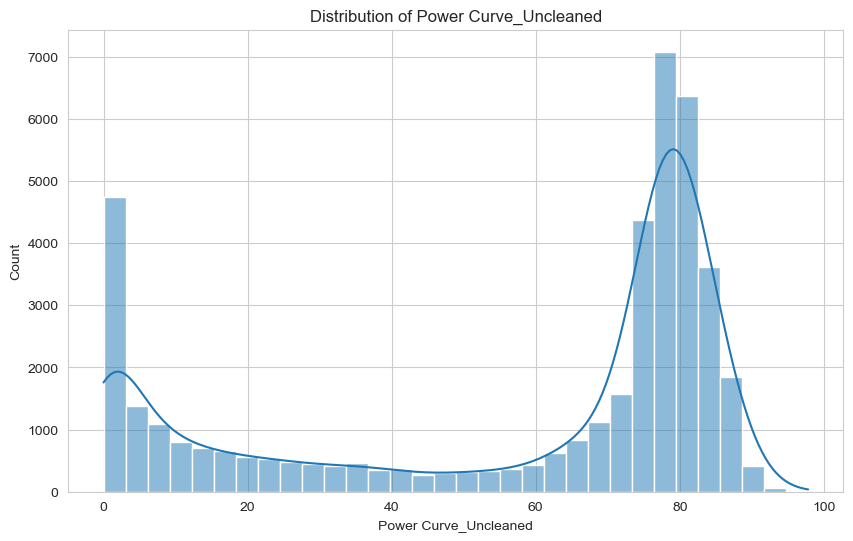

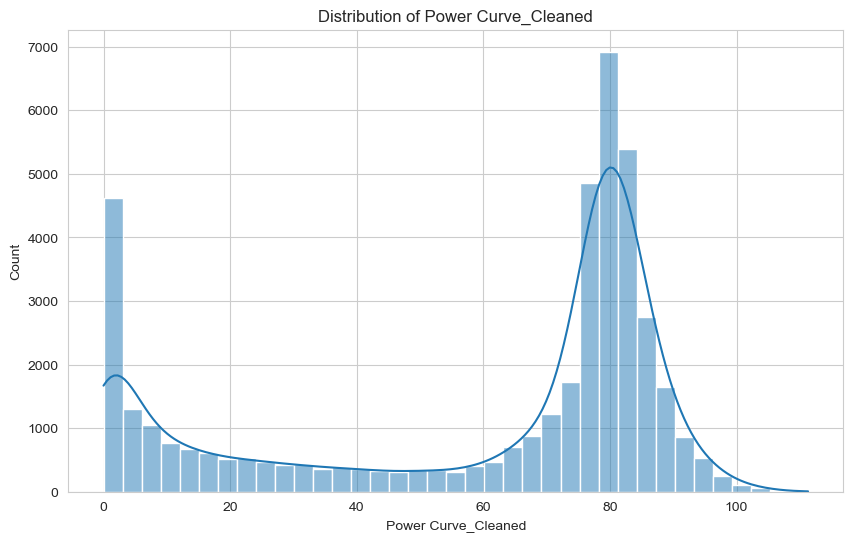

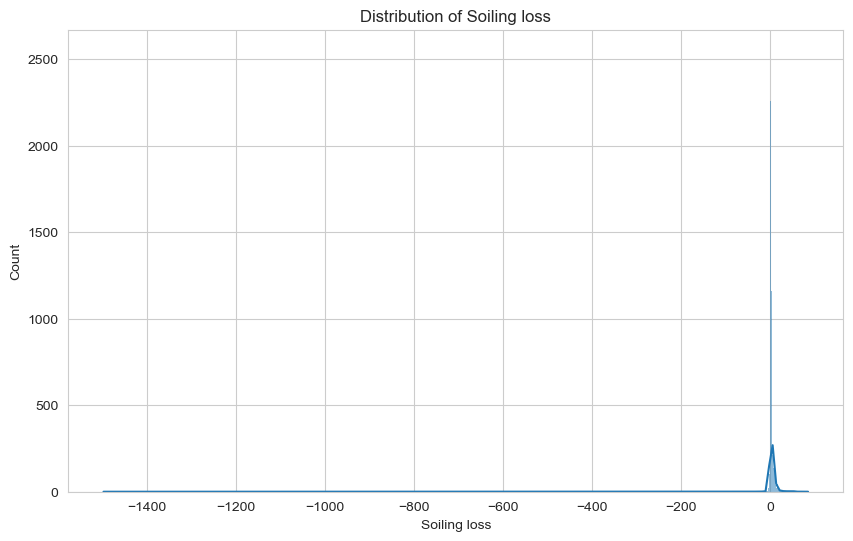

In [22]:
cols = [
    "Uncleaned_Voltage", "Cleaned_Voltage",
    "Uncleaned_Current", "Cleaned_Current",
    "Power Curve_Uncleaned", "Power Curve_Cleaned",
    "Soiling loss"
]

for col in cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


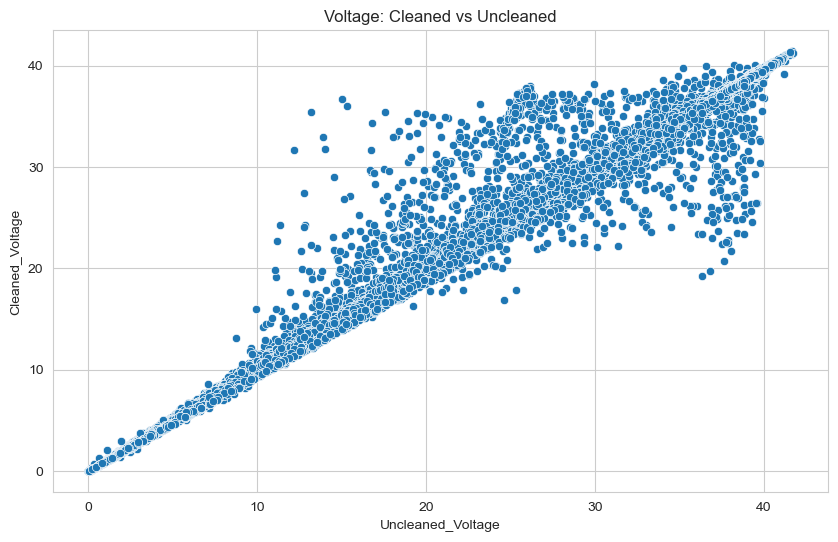

In [23]:
plt.figure()
sns.scatterplot(x=df["Uncleaned_Voltage"], y=df["Cleaned_Voltage"])
plt.title("Voltage: Cleaned vs Uncleaned")
plt.show()


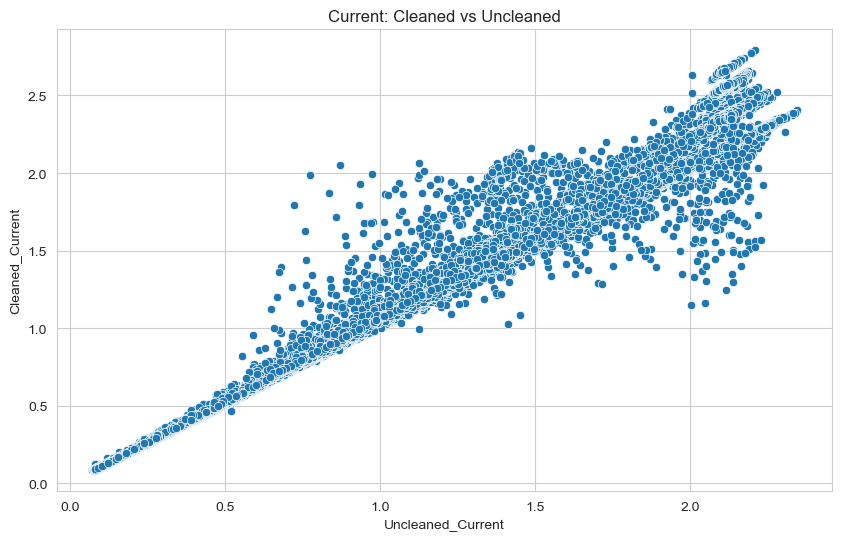

In [35]:
plt.figure()
sns.scatterplot(x=df["Uncleaned_Current"], y=df["Cleaned_Current"])
plt.title("Current: Cleaned vs Uncleaned")
plt.show()


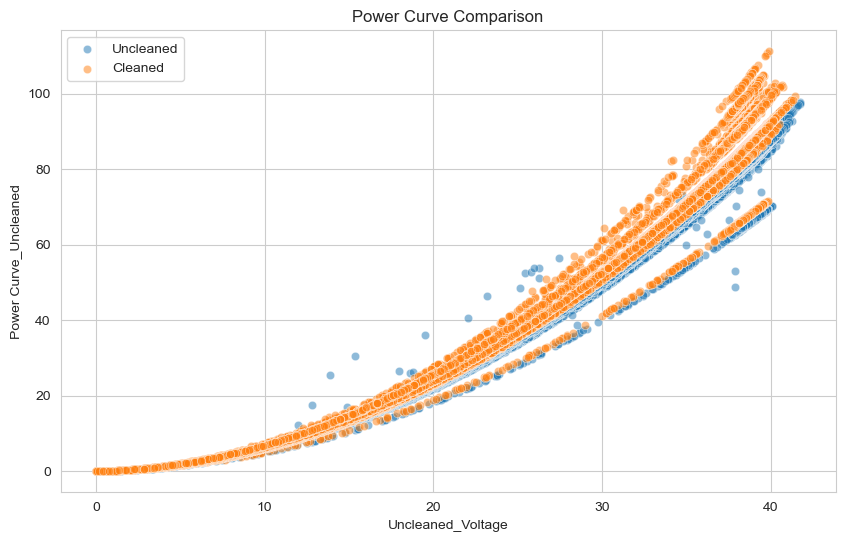

In [36]:
plt.figure()
sns.scatterplot(x=df["Uncleaned_Voltage"],
                y=df["Power Curve_Uncleaned"],
                alpha=0.5)

sns.scatterplot(x=df["Cleaned_Voltage"],
                y=df["Power Curve_Cleaned"],
                alpha=0.5)

plt.title("Power Curve Comparison")
plt.legend(["Uncleaned", "Cleaned"])
plt.show()


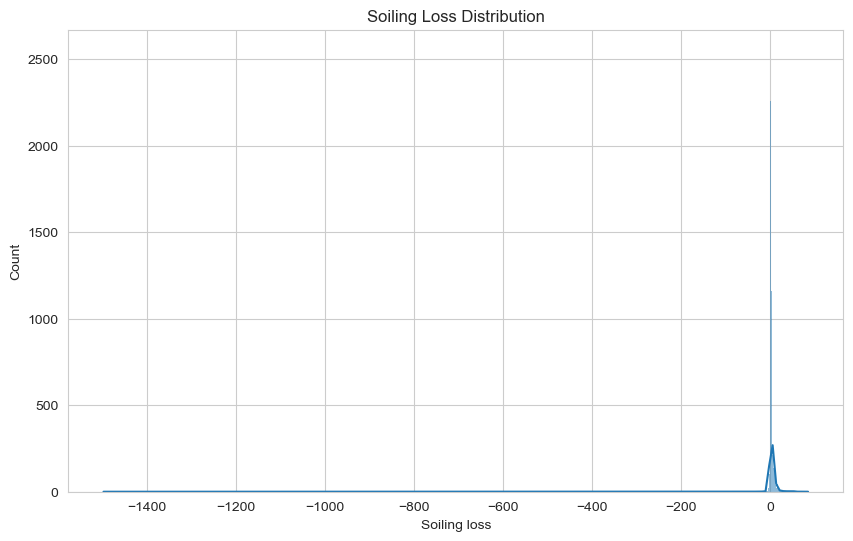

In [37]:
plt.figure()
sns.histplot(df["Soiling loss"], kde=True)
plt.title("Soiling Loss Distribution")
plt.show()


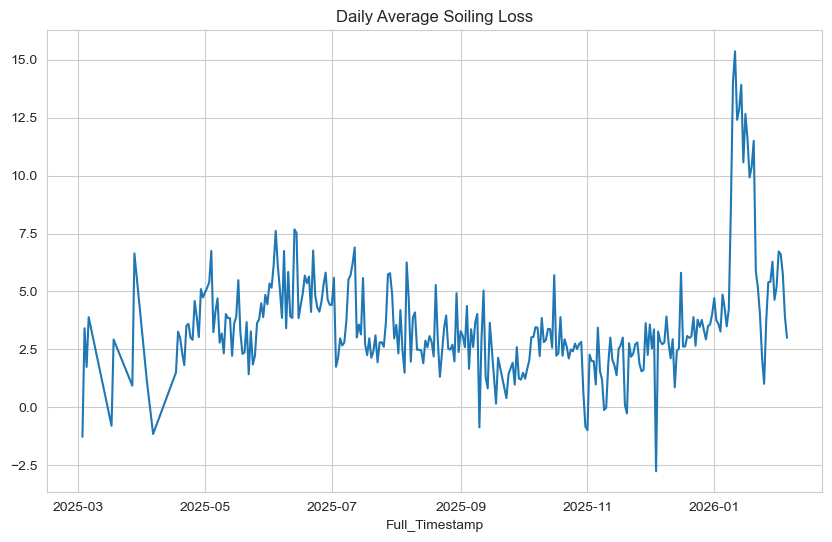

In [38]:
daily_soiling = df.groupby(df["Full_Timestamp"].dt.date)["Soiling loss"].mean()

plt.figure()
daily_soiling.plot()
plt.title("Daily Average Soiling Loss")
plt.show()


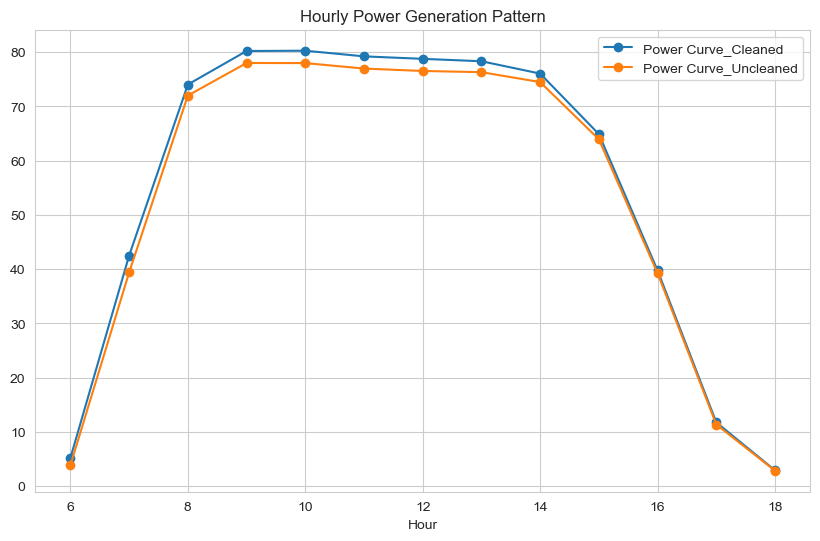

In [39]:
hourly_power = df.groupby("Hour")[["Power Curve_Cleaned", "Power Curve_Uncleaned"]].mean()

hourly_power.plot(marker='o')
plt.title("Hourly Power Generation Pattern")
plt.show()


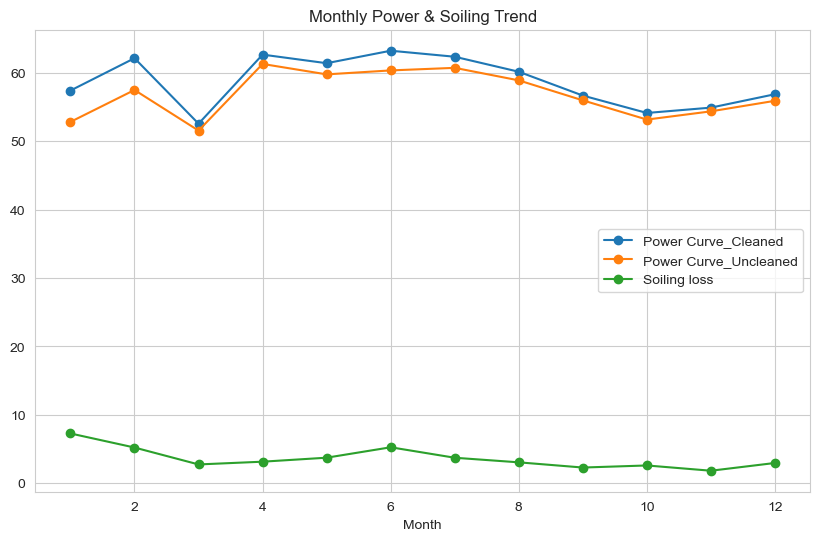

In [40]:
monthly_power = df.groupby("Month")[["Power Curve_Cleaned",
                                     "Power Curve_Uncleaned",
                                     "Soiling loss"]].mean()

monthly_power.plot(marker='o')
plt.title("Monthly Power & Soiling Trend")
plt.show()


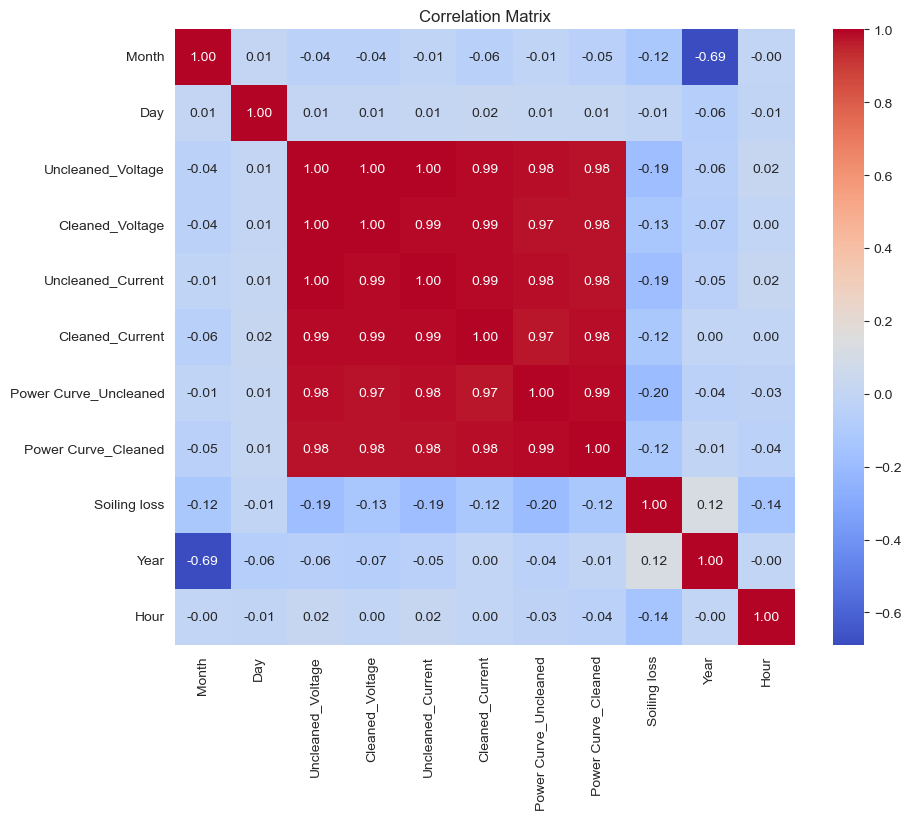

In [41]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


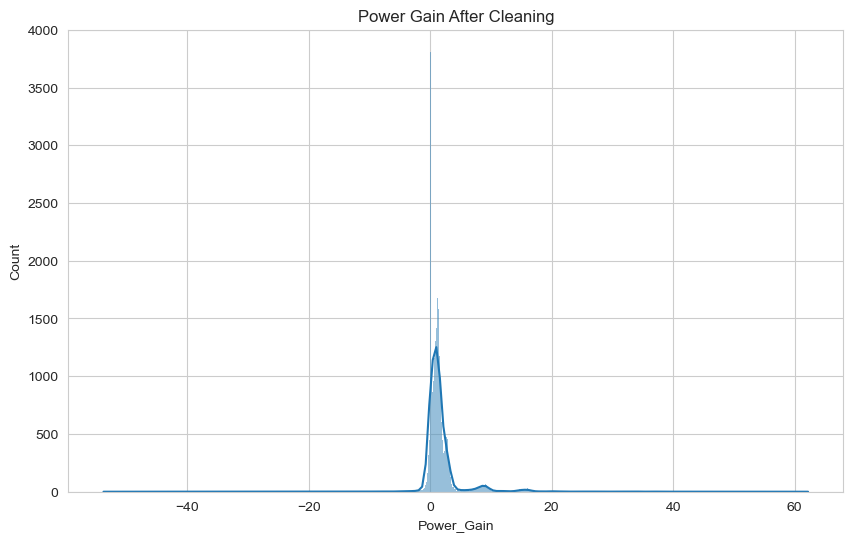

Average Power Gain: 1.7244068609771304


In [42]:
df["Power_Gain"] = df["Power Curve_Cleaned"] - df["Power Curve_Uncleaned"]

plt.figure()
sns.histplot(df["Power_Gain"], kde=True)
plt.title("Power Gain After Cleaning")
plt.show()

print("Average Power Gain:", df["Power_Gain"].mean())


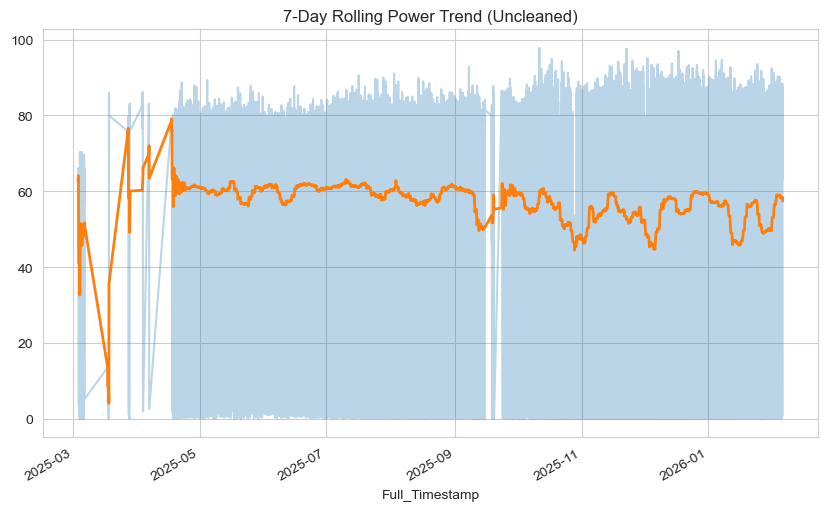

In [43]:
df.set_index("Full_Timestamp", inplace=True)

rolling_power = df["Power Curve_Uncleaned"].rolling("7D").mean()

plt.figure()
df["Power Curve_Uncleaned"].plot(alpha=0.3)
rolling_power.plot(linewidth=2)
plt.title("7-Day Rolling Power Trend (Uncleaned)")
plt.show()


In [44]:
Q1 = df["Soiling loss"].quantile(0.25)
Q3 = df["Soiling loss"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Soiling loss"] < Q1 - 1.5*IQR) |
              (df["Soiling loss"] > Q3 + 1.5*IQR)]

print("Outliers in Soiling Loss:", len(outliers))


Outliers in Soiling Loss: 5601


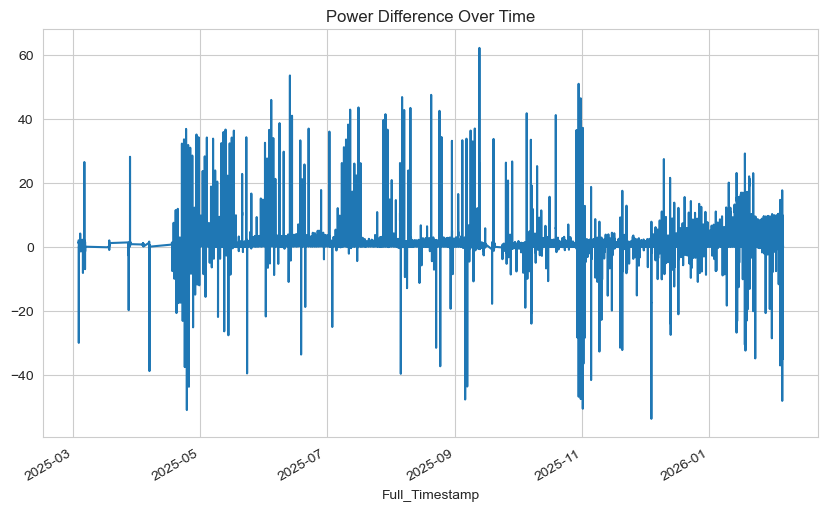

In [45]:
df["Power_Diff"] = df["Power Curve_Cleaned"] - df["Power Curve_Uncleaned"]

plt.figure()
df["Power_Diff"].plot()
plt.title("Power Difference Over Time")
plt.show()
